# 06 — Goodreads validation: quality against reach

Every result so far has used one outcome: how highly readers rated a book. Goodreads gives us
a second, independent signal — how many readers rated it at all. This notebook asks whether
the two say the same thing, and what changes when they disagree.

The distinction matters because "successful romance novel" hides two different questions:

- **Quality** — of the people who read it, how much did they like it? (`rating_shrunk`)
- **Reach** — how many people found it in the first place? (`log_n_ratings`)

A book can score well on one and badly on the other. A quiet novel with 40 devoted readers
averaging 4.6 stars is high quality, low reach. A heavily marketed series entry with 30,000
ratings averaging 3.6 is the reverse. Collapsing them into one "success" number would blur
a distinction the data clearly contains.

**What this notebook is for.** Two things, and they pull in opposite directions:

1. *Validation.* If a theme predicts both channels in the same direction, that is harder to
   dismiss as an artefact of one particular metric. Agreement across two imperfect measures
   is weak evidence, but it is evidence.
2. *Discrimination.* Where the channels disagree, the disagreement is itself the finding.
   A theme that raises reach but not rating is doing commercial work, not aesthetic work.

**One caution to carry throughout.** Reach is not a reader-preference measure. It is mostly
a publishing and marketing measure — how well distributed a book was, whether it sat in a
popular series, how long it had been available. Themes will look weaker against it, and
should.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sps

from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import models as mdl
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh
from src.stage10_correlation_analysis.analysis import tests as tst

ctx = nbh.setup("06_goodreads_validation")
cfg = ctx.cfg
TIERS = cfg.tier_order
TIER_COL = cfg.tier_column
PALETTE = nbh.tier_palette(cfg)
HIGH, LOW = cfg.section("tiers", "headline_contrast")
GATE = float(cfg.section("screening", "effect_gates", "cliffs_delta_small"))
ALPHA = float(cfg.section("inference", "fdr_alpha"))
SEED = int(cfg.section("inference", "bootstrap", "seed"))
REPLICATES = int(cfg.section("inference", "screening_ci_replicates"))

QUALITY = "rating_shrunk"
QUALITY_RAW = "avg_rating"
REACH = "log_n_ratings"
WEIGHT = cfg.section("outcomes", "quality", "weight")
MIN_RATINGS = int(cfg.section("outcomes", "quality", "sensitivity_min_ratings"))
CONTROLS = list(cfg.section("controls", "numeric"))
CATEGORICAL = list(cfg.section("controls", "categorical"))
CLUSTER = cfg.section("controls", "cluster")

frame = nbh.load_analysis_frame(cfg).reset_index()
topic_lookup = nbh.load_topic_lookup(cfg)
leaf_labels = nbh.leaf_label_map(topic_lookup, prefix="abs_leaf_")

LEAF_COLS = [
    c for c in nbh.columns_with_prefix(frame, "abs_leaf_")
    if not c.endswith(("unmapped", "uncertain_interpretable"))
]
AXES = sorted({
    c[:-4] for c in frame.columns
    if c.startswith("AX_") and c.endswith("_clr")
})

print(f"\n{len(frame):,} books, {len(LEAF_COLS)} taxonomy leaves, {len(AXES)} axes.")
print(f"Quality: {QUALITY} (weighted by {WEIGHT}) | Reach: {REACH}")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation



16,000 books, 45 taxonomy leaves, 28 axes.
Quality: rating_shrunk (weighted by reliability) | Reach: log_n_ratings


## 1. How different are the two channels, really?

Before treating them as separate, it is worth checking that they *are* separate. If quality
and reach correlated at 0.8, this notebook would be redundant.

In [2]:
pair = frame[[QUALITY, QUALITY_RAW, REACH, "n_ratings"]].dropna()
correlations = pd.DataFrame([
    {
        "pair": "shrunk rating vs log ratings count",
        "pearson_r": sps.pearsonr(pair[QUALITY], pair[REACH])[0],
        "spearman_rho": sps.spearmanr(pair[QUALITY], pair[REACH])[0],
    },
    {
        "pair": "raw rating vs log ratings count",
        "pearson_r": sps.pearsonr(pair[QUALITY_RAW], pair[REACH])[0],
        "spearman_rho": sps.spearmanr(pair[QUALITY_RAW], pair[REACH])[0],
    },
    {
        "pair": "raw rating vs shrunk rating",
        "pearson_r": sps.pearsonr(pair[QUALITY_RAW], pair[QUALITY])[0],
        "spearman_rho": sps.spearmanr(pair[QUALITY_RAW], pair[QUALITY])[0],
    },
])
display(correlations.round(4))
ctx.save_table(correlations, "channel_correlations")

shrunk_r = correlations.iloc[0]["pearson_r"]
raw_r = correlations.iloc[1]["pearson_r"]
print(
    f"\nShrunk rating and reach share {shrunk_r ** 2 * 100:.1f}% of their variance; "
    f"raw rating and reach\nshare {raw_r ** 2 * 100:.1f}%. Either way, the large majority of "
    "what makes a book well-rated is\nunrelated to how many people rated it. That is the "
    "justification for this notebook."
)
print(
    f"\nWhy the shrunk channel correlates more strongly with reach ({shrunk_r:.3f}) than the raw\n"
    f"channel does ({raw_r:.3f}): shrinkage pulls low-count books toward the corpus mean, and\n"
    "low-count books are exactly the low-reach books. Some of that 0.21 is therefore built in\n"
    "by construction rather than discovered. It is a reason to read the shrunk-versus-reach\n"
    "correlation as an upper bound, and a reason section 6 re-runs everything on raw ratings."
)
print(
    f"\nRaw and shrunk ratings correlate at r = {correlations.iloc[2]['pearson_r']:.3f} but "
    f"rho = {correlations.iloc[2]['spearman_rho']:.3f}.\n"
    "The gap between those two numbers is the whole effect of shrinkage: it barely changes how\n"
    "books are *ordered*, and substantially compresses how far apart they are placed."
)

,pair,pearson_r,spearman_rho
0,shrunk rating vs log ratings count,0.2061,0.1560
1,raw rating vs log ratings count,0.1241,0.0970
2,raw rating vs shrunk rating,0.7578,0.8968


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/channel_correlations.csv  (3 rows)

Shrunk rating and reach share 4.2% of their variance; raw rating and reach
share 1.5%. Either way, the large majority of what makes a book well-rated is
unrelated to how many people rated it. That is the justification for this notebook.

Why the shrunk channel correlates more strongly with reach (0.206) than the raw
channel does (0.124): shrinkage pulls low-count books toward the corpus mean, and
low-count books are exactly the low-reach books. Some of that 0.21 is therefore built in
by construction rather than discovered. It is a reason to read the shrunk-versus-reach
correlation as an upper bound, and a reason section 6 re-runs everything on raw ratings.

Raw and shrunk ratings correlate at r = 0.758 but rho = 0.897.
The gap between those two numbers is the whole effect of shrinkage: it barely changes how
books are *orde

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/figures/two_channels_overview.png


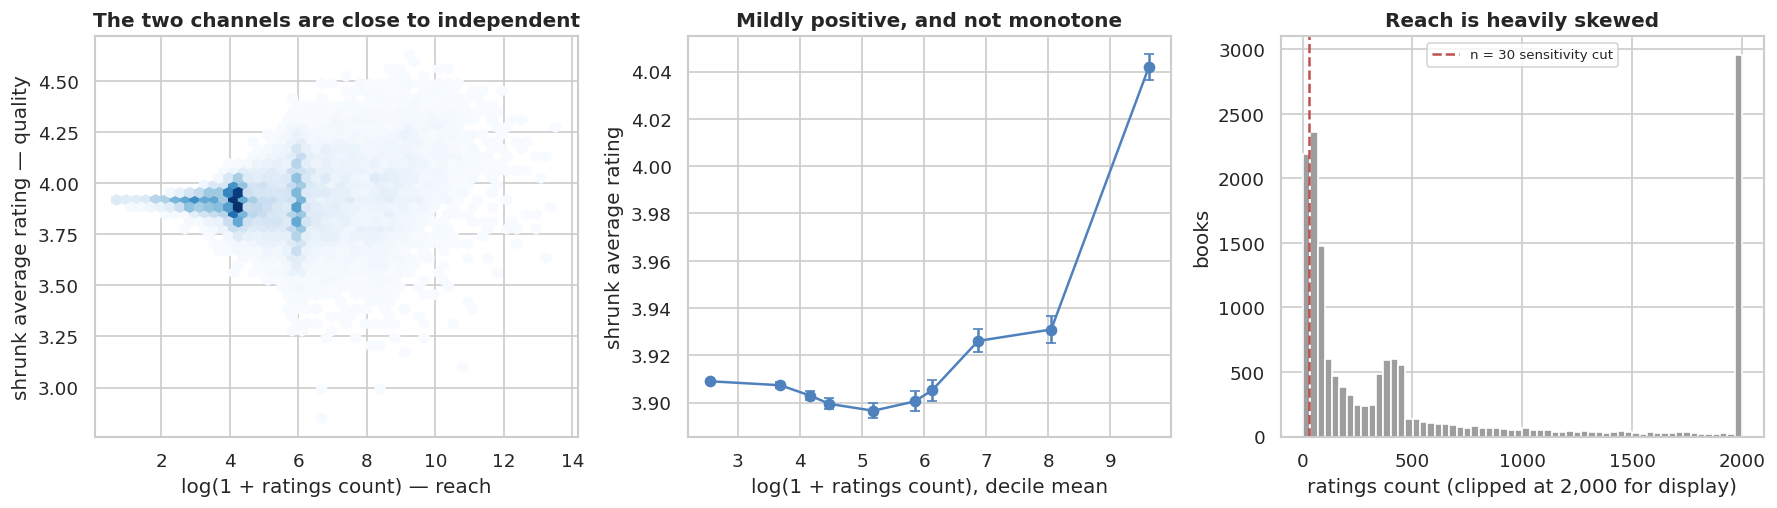

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/rating_by_reach_decile.csv  (10 rows)

1,909 books (11.9%) have fewer than 30 ratings. Their
average rating is a small-sample estimate, which is why the quality channel is fit
weighted by reliability and re-fit on the n >= 30 subset in section 6.


In [3]:
fig, axes_row = plt.subplots(1, 3, figsize=(15, 4.4))

axes_row[0].hexbin(pair[REACH], pair[QUALITY], gridsize=45, cmap="Blues", mincnt=1)
axes_row[0].set_xlabel("log(1 + ratings count) — reach")
axes_row[0].set_ylabel("shrunk average rating — quality")
axes_row[0].set_title("The two channels are close to independent")

deciles = pair.copy()
deciles["reach_decile"] = pd.qcut(deciles[REACH], 10, labels=False, duplicates="drop")
profile = deciles.groupby("reach_decile").agg(
    reach=(REACH, "mean"), rating=(QUALITY, "mean"),
    sem=(QUALITY, lambda s: s.std() / np.sqrt(len(s))), n=(QUALITY, "size"),
).reset_index()
axes_row[1].errorbar(profile["reach"], profile["rating"], yerr=profile["sem"],
                     marker="o", color="#4f81bd", capsize=3)
axes_row[1].set_xlabel("log(1 + ratings count), decile mean")
axes_row[1].set_ylabel("shrunk average rating")
axes_row[1].set_title("Mildly positive, and not monotone")

axes_row[2].hist(pair["n_ratings"].clip(upper=2000), bins=60, color="#9e9e9e")
axes_row[2].axvline(MIN_RATINGS, color="#c0504d", ls="--",
                    label=f"n = {MIN_RATINGS} sensitivity cut")
axes_row[2].set_xlabel("ratings count (clipped at 2,000 for display)")
axes_row[2].set_ylabel("books")
axes_row[2].set_title("Reach is heavily skewed")
axes_row[2].legend(fontsize=8)

fig.tight_layout()
ctx.save_figure(fig, "two_channels_overview")
plt.show()
ctx.save_table(profile, "rating_by_reach_decile")

thin = int((frame["n_ratings"] < MIN_RATINGS).sum())
print(
    f"\n{thin:,} books ({thin / len(frame) * 100:.1f}%) have fewer than {MIN_RATINGS} ratings. "
    "Their\naverage rating is a small-sample estimate, which is why the quality channel is fit\n"
    "weighted by reliability and re-fit on the n >= 30 subset in section 6."
)

## 2. What each channel is actually made of

A useful calibration before testing themes: how much of each channel do the *controls* alone
explain? If length, era and genre already account for most of reach, then reach is largely a
market variable and we should not expect themes to move it.

In [4]:
control_fits = [
    mdl.fit_ols(frame, QUALITY, CONTROLS, categorical=CATEGORICAL, cluster=CLUSTER,
                weights=WEIGHT, name="quality ~ controls"),
    mdl.fit_ols(frame, REACH, CONTROLS, categorical=CATEGORICAL, cluster=CLUSTER,
                name="reach ~ controls"),
]
baseline = pd.DataFrame([
    {"channel": f.name, "n_obs": f.n_obs, "r_squared": f.r_squared,
     "adj_r_squared": f.extra["adj_r_squared"]}
    for f in control_fits
])
display(baseline.round(4))
ctx.save_table(baseline, "controls_only_baselines")
ctx.save_table(mdl.tidy_fits(control_fits), "controls_only_coefficients")

q_r2, r_r2 = baseline["r_squared"].iloc[0], baseline["r_squared"].iloc[1]
print(
    f"\nControls explain {r_r2 * 100:.1f}% of reach and {q_r2 * 100:.1f}% of quality — "
    "almost the same amount.\nThat was not the expected answer; reach looked like it should be "
    "far more predictable from\nlength, era and genre than rating is. The coefficients below "
    "show why the R-squareds match\nwhile meaning quite different things."
)

,channel,n_obs,r_squared,adj_r_squared
0,quality ~ controls,16000,0.1119,0.1115
1,reach ~ controls,16000,0.1248,0.1244


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/controls_only_baselines.csv  (2 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/controls_only_coefficients.csv  (14 rows)

Controls explain 12.5% of reach and 11.2% of quality — almost the same amount.
That was not the expected answer; reach looked like it should be far more predictable from
length, era and genre than rating is. The coefficients below show why the R-squareds match
while meaning quite different things.


The two coefficient sets are worth comparing directly, because they say what each channel is
sensitive to:

- **Publication year** moves reach by about −0.10 log-ratings per year. Over the corpus's
  2000–2017 span that is a factor of roughly five: older books have simply had longer to
  accumulate ratings. On quality the year coefficient is +0.011 rating points per year, which
  is real but small.
- **Length** moves reach hard (+1.09 log-ratings per log-page) and quality gently (+0.086).
  Longer romances reach many more readers and are rated slightly higher.
- **Genre** matters far more for reach than for quality. Young-adult romance carries +1.31 in
  log-ratings — a threefold reach advantage — against essentially zero on rating.

So the channels are equally *predictable* but from different mechanisms: reach responds to
exposure and market position, quality to something much flatter. Reach is largely not a
measure of appeal, and themes should not be expected to move it much.

In [5]:
era = frame.groupby("year_bin", observed=True).agg(
    books=("n_ratings", "size"),
    median_ratings=("n_ratings", "median"),
    mean_shrunk_rating=(QUALITY, "mean"),
).reset_index()
display(era.round(3))
ctx.save_table(era, "channels_by_era")
print(
    "\nMedian ratings count falls from 424 in the earliest bin to 151 in the latest — a factor\n"
    "of nearly three — while mean shrunk rating rises only from 3.89 to 3.97. The era effect on\n"
    "reach is large and the era effect on quality is small, so controlling for year matters much\n"
    "more to the reach channel. Notebook 08 re-runs the headline results within era bins.\n"
)
print(
    "Note also that the corpus is far from evenly spread: 10,863 of 16,000 books fall in\n"
    "2010-2014. The earliest and latest bins are thin by comparison, so era-specific claims\n"
    "outside the middle of the range rest on much less data."
)

,year_bin,books,median_ratings,mean_shrunk_rating
0,2000-2004,722,423.5000,3.8910
1,2005-2009,2102,432.0000,3.8790
2,2010-2014,10863,239.0000,3.9220
3,2015-2019,2313,151.0000,3.9720


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/channels_by_era.csv  (4 rows)

Median ratings count falls from 424 in the earliest bin to 151 in the latest — a factor
of nearly three — while mean shrunk rating rises only from 3.89 to 3.97. The era effect on
reach is large and the era effect on quality is small, so controlling for year matters much
more to the reach channel. Notebook 08 re-runs the headline results within era bins.

Note also that the corpus is far from evenly spread: 10,863 of 16,000 books fall in
2010-2014. The earliest and latest bins are thin by comparison, so era-specific claims
outside the middle of the range rest on much less data.


## 3. Every axis against both channels, on one scale

The comparison needs both channels on comparable footing. A coefficient in rating points and
a coefficient in log-ratings-count cannot be read side by side, so both outcome and predictor
are standardised: each reported beta is the change in outcome standard deviations per
predictor standard deviation, controlling for length, era and genre, with author-clustered
standard errors.

This makes the two numbers per axis directly comparable, which is the only thing needed to
classify an axis as acting on quality, on reach, on both, or on neither.

In [6]:
def standardised(series: pd.Series) -> pd.Series:
    sd = series.std(ddof=0)
    return (series - series.mean()) / sd if sd > 0 else series * 0.0


def two_channel_betas(columns, *, label_map=None, use_clr=True) -> pd.DataFrame:
    """Standardised partial betas on both channels for each column."""
    work = frame.copy()
    work["_q"] = standardised(work[QUALITY])
    work["_r"] = standardised(work[REACH])
    rows = []
    for col in columns:
        predictor = f"{col}_clr" if use_clr and f"{col}_clr" in work.columns else col
        if predictor not in work.columns:
            continue
        work["_x"] = standardised(work[predictor])
        if work["_x"].std(ddof=0) == 0:
            continue
        record = {
            "feature": col,
            "label": (label_map or {}).get(col, col),
            "predictor": predictor,
            "scale": "CLR" if predictor.endswith("_clr") else "raw share",
        }
        for channel, outcome, weights in (("quality", "_q", WEIGHT), ("reach", "_r", None)):
            fit = mdl.fit_ols(
                work, outcome, ["_x", *CONTROLS], categorical=CATEGORICAL,
                cluster=CLUSTER, weights=weights, name=f"{col}->{channel}",
            )
            row = fit.coefficients[fit.coefficients["term"] == "_x"].iloc[0]
            record[f"{channel}_beta"] = float(row["coefficient"])
            record[f"{channel}_se"] = float(row["std_error"])
            record[f"{channel}_p"] = float(row["p_value"])
            record[f"{channel}_ci_low"] = float(row["ci_low"])
            record[f"{channel}_ci_high"] = float(row["ci_high"])
        rows.append(record)
    return pd.DataFrame(rows)


def flag_reliable(table: pd.DataFrame) -> pd.DataFrame:
    """BH q-values within each channel, plus a 'reliable' flag combining q and CI sign."""
    out = table.copy()
    for channel in ("quality", "reach"):
        out[f"{channel}_q"] = tst.benjamini_hochberg(out[f"{channel}_p"].to_numpy())
        out[f"{channel}_reliable"] = (
            (out[f"{channel}_q"] < ALPHA)
            & (np.sign(out[f"{channel}_ci_low"]) == np.sign(out[f"{channel}_ci_high"]))
        )
    return out


axis_channels = flag_reliable(two_channel_betas(AXES))

print(f"{len(axis_channels)} axes fit against both channels, "
      f"BH-corrected within each channel at alpha = {ALPHA}.")

28 axes fit against both channels, BH-corrected within each channel at alpha = 0.05.


### The quadrant classification

Four possible patterns, and each means something different:

| Pattern | Reading |
|---|---|
| **both, same sign** | The theme travels with both liking and finding. The strongest claim available here. |
| **quality only** | Readers who read it liked it more, but it did not reach more readers. An aesthetic effect without a commercial one. |
| **reach only** | More readers found it, without liking it more. Commercial or marketing signal. |
| **opposite signs** | A genuine trade-off: the theme buys audience at the cost of appreciation, or the reverse. |

In [7]:
def classify(row) -> str:
    q_ok, r_ok = row["quality_reliable"], row["reach_reliable"]
    if q_ok and r_ok:
        return "both, same sign" if np.sign(row["quality_beta"]) == np.sign(row["reach_beta"]) \
            else "opposite signs"
    if q_ok:
        return "quality only"
    if r_ok:
        return "reach only"
    return "neither"


axis_channels["pattern"] = axis_channels.apply(classify, axis=1)
axis_channels["beta_gap"] = axis_channels["quality_beta"] - axis_channels["reach_beta"]
axis_channels = axis_channels.sort_values("quality_beta", ascending=False).reset_index(drop=True)

display(nbh.summarise_counts(axis_channels, "pattern"))
ctx.save_table(axis_channels, "axis_two_channel_betas")

view = axis_channels[[
    "label", "quality_beta", "quality_q", "reach_beta", "reach_q", "beta_gap", "pattern",
]].copy()
view["label"] = view["label"].str.replace("AX_", "", regex=False)
display(view.round(4).head(30))

,pattern,n,percent
0,reach only,10,35.7000
1,"both, same sign",7,25.0000
2,quality only,6,21.4000
3,neither,4,14.3000
4,opposite signs,1,3.6000


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/axis_two_channel_betas.csv  (28 rows)


,label,quality_beta,quality_q,reach_beta,reach_q,beta_gap,pattern
0,explicitness_ratio,0.1703,0.0000,0.1341,0.0000,0.0362,"both, same sign"
1,violence_coercion,0.1688,0.0000,0.0205,0.1143,0.1483,quality only
2,coercion_risk_watchlist,0.1605,0.0000,0.0180,0.1471,0.1425,quality only
3,explicitness,0.1408,0.0000,0.1923,0.0000,-0.0515,"both, same sign"
4,sexual_tension_explicit_intimacy,0.1115,0.0000,0.1130,0.0000,-0.0015,"both, same sign"
5,dysregulated_negative_affect,0.0565,0.0046,0.0366,0.0007,0.0199,"both, same sign"
6,protective_care_resid,0.0513,0.0051,0.0179,0.1573,0.0334,quality only
7,protective_care,0.0453,0.0051,0.0211,0.0395,0.0243,"both, same sign"
8,payoff_safety_fallback,0.0294,0.0950,0.0425,0.0000,-0.0131,reach only
9,attraction,0.0259,0.2198,-0.0063,0.6000,0.0322,neither


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/figures/axis_quadrant.png


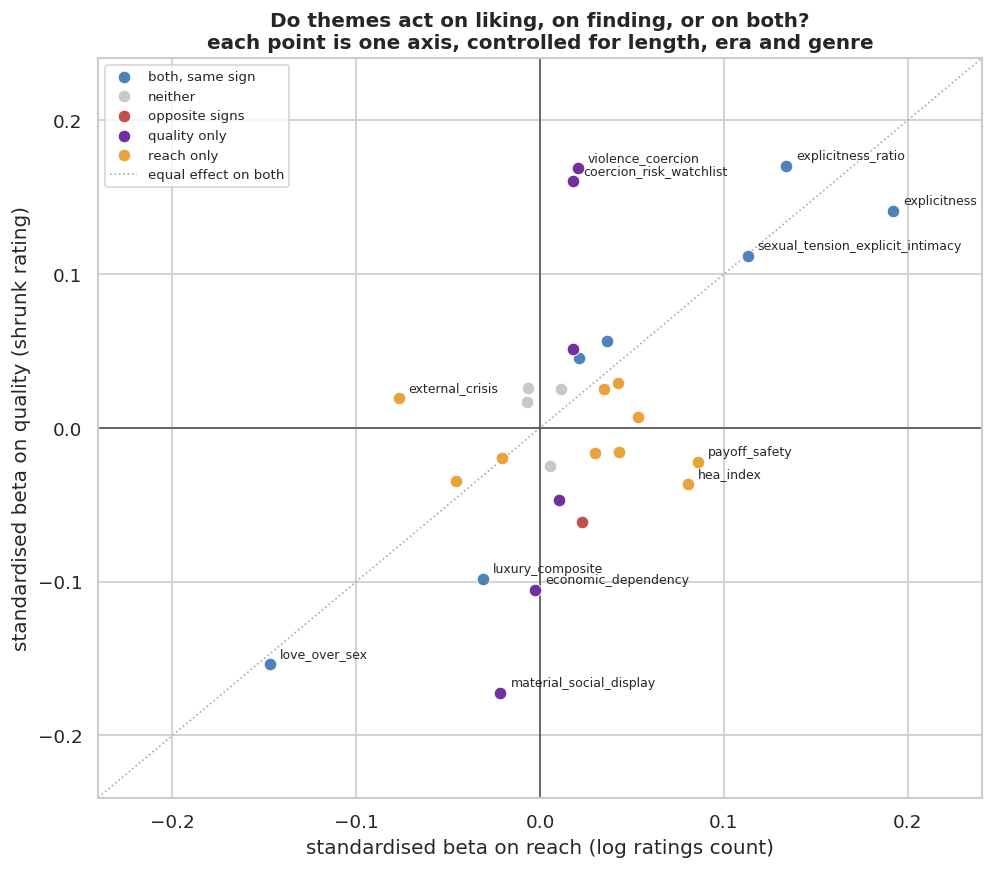

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 8))
colours = {
    "both, same sign": "#4f81bd", "quality only": "#7030a0",
    "reach only": "#e8a33d", "opposite signs": "#c0504d", "neither": "#c8c8c8",
}
for pattern, group in axis_channels.groupby("pattern"):
    ax.scatter(group["reach_beta"], group["quality_beta"], s=58,
               color=colours.get(pattern, "#888888"), label=pattern,
               edgecolor="white", linewidth=0.6, zorder=3)

ax.axhline(0, color="#555555", lw=1)
ax.axvline(0, color="#555555", lw=1)
limit = float(np.nanmax(np.abs(
    np.concatenate([axis_channels["reach_beta"], axis_channels["quality_beta"]])
))) * 1.25
ax.plot([-limit, limit], [-limit, limit], color="#aaaaaa", ls=":", lw=1,
        label="equal effect on both", zorder=1)

notable = axis_channels.reindex(
    axis_channels[["quality_beta", "reach_beta"]].abs().max(axis=1).nlargest(12).index
)
for row in notable.itertuples():
    ax.annotate(row.label.replace("AX_", ""),
                (row.reach_beta, row.quality_beta),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_xlabel("standardised beta on reach (log ratings count)")
ax.set_ylabel("standardised beta on quality (shrunk rating)")
ax.set_title("Do themes act on liking, on finding, or on both?\n"
             "each point is one axis, controlled for length, era and genre")
ax.legend(fontsize=8, loc="upper left")
ctx.save_figure(fig, "axis_quadrant")
plt.show()

The axis-level picture already shows the pattern that section 5 confirms at leaf level.

*Quality only* (6 axes) includes the two strongest results in the whole analysis: material and
social display at −0.172 and violence/coercion at +0.169, both with essentially nothing on
reach. These are aesthetic effects with no market signature.

*Reach only* (10 axes) is the largest group, and the HEA index sits in it — +0.081 on reach,
−0.036 on quality. Notebook 05 recorded H2 as a null; it was a null in one channel only.

*Both, same sign* (7 axes) is led by the two explicitness axes, which is a genuine
double effect: explicit content travels with both more readers and, once books are
reliability-weighted, higher ratings among them.

*Opposite signs* has exactly one member, `AX_miscommunication`: −0.061 on quality, +0.023 on
reach. A small, clean trade-off — the misunderstanding plot draws readers and costs approval.

The `AX_love_over_sex` position deserves a note, because it is negative on *both* channels
(−0.153, −0.147). The axis is a ratio with explicit sex in the denominator, so a negative
coefficient means higher explicitness is associated with both channels rising. That is H1's
reversal restated, and the two channels agree on it.

## 4. The same question at leaf level

Axes are constructed objects, and notebook 04 showed that most of them do not hold together
internally. The taxonomy leaves are the more trustworthy unit, so the two-channel comparison
is repeated across all of them. This is also the wider net: leaves that no hypothesis
mentions get their chance here.

In [9]:
leaf_channels = flag_reliable(
    two_channel_betas(LEAF_COLS, label_map=leaf_labels, use_clr=False)
)
leaf_channels["pattern"] = leaf_channels.apply(classify, axis=1)
leaf_channels["beta_gap"] = leaf_channels["quality_beta"] - leaf_channels["reach_beta"]
leaf_channels = leaf_channels.sort_values("quality_beta", ascending=False).reset_index(drop=True)

display(nbh.summarise_counts(leaf_channels, "pattern"))
ctx.save_table(leaf_channels, "leaf_two_channel_betas")

,pattern,n,percent
0,neither,14,31.1000
1,reach only,10,22.2000
2,"both, same sign",8,17.8000
3,quality only,7,15.6000
4,opposite signs,6,13.3000


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/leaf_two_channel_betas.csv  (45 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/figures/leaf_quadrant.png


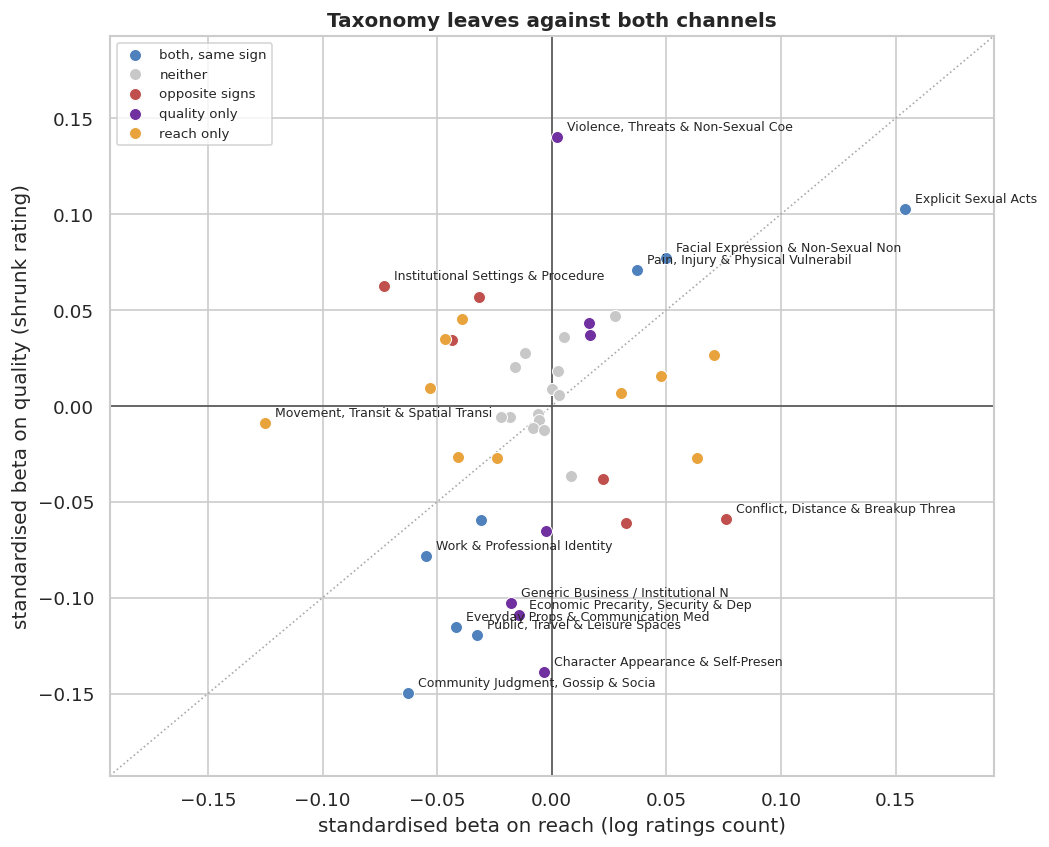

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 8))
for pattern, group in leaf_channels.groupby("pattern"):
    ax.scatter(group["reach_beta"], group["quality_beta"], s=52,
               color=colours.get(pattern, "#888888"), label=pattern,
               edgecolor="white", linewidth=0.6, zorder=3)
ax.axhline(0, color="#555555", lw=1)
ax.axvline(0, color="#555555", lw=1)
limit = float(np.nanmax(np.abs(
    np.concatenate([leaf_channels["reach_beta"], leaf_channels["quality_beta"]])
))) * 1.25
ax.plot([-limit, limit], [-limit, limit], color="#aaaaaa", ls=":", lw=1, zorder=1)
notable = leaf_channels.reindex(
    leaf_channels[["quality_beta", "reach_beta"]].abs().max(axis=1).nlargest(14).index
)
for row in notable.itertuples():
    short = row.label.split(" — ")[-1] if " — " in row.label else row.label
    ax.annotate(short[:34], (row.reach_beta, row.quality_beta),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_xlabel("standardised beta on reach (log ratings count)")
ax.set_ylabel("standardised beta on quality (shrunk rating)")
ax.set_title("Taxonomy leaves against both channels")
ax.legend(fontsize=8, loc="upper left")
ctx.save_figure(fig, "leaf_quadrant")
plt.show()

In [11]:
agreement = leaf_channels[["quality_beta", "reach_beta"]].dropna()
r_agree = sps.pearsonr(agreement["quality_beta"], agreement["reach_beta"])
rho_agree = sps.spearmanr(agreement["quality_beta"], agreement["reach_beta"])
same_sign = float(
    (np.sign(agreement["quality_beta"]) == np.sign(agreement["reach_beta"])).mean()
)
print(
    f"Across {len(agreement)} leaves, the two channels' betas correlate at "
    f"r = {r_agree[0]:+.3f} (rho = {rho_agree[0]:+.3f}),\n"
    f"and {same_sign * 100:.0f}% of leaves point the same way on both.\n"
)
print("Leaves whose channels disagree most sharply:")
display(
    leaf_channels.reindex(leaf_channels["beta_gap"].abs().nlargest(10).index)[
        ["label", "quality_beta", "reach_beta", "beta_gap", "pattern"]
    ].round(4)
)

Across 45 leaves, the two channels' betas correlate at r = +0.286 (rho = +0.246),
and 71% of leaves point the same way on both.

Leaves whose channels disagree most sharply:


,label,quality_beta,reach_beta,beta_gap,pattern
0,"Violence, Threats & Non-Sexual Coercion",0.1405,0.0025,0.1380,quality only
43,Character Appearance & Self-Presentation,-0.1390,-0.0033,-0.1357,quality only
4,Institutional Settings & Procedures,0.0626,-0.0730,0.1356,opposite signs
34,"Conflict, Distance & Breakup Threats",-0.0589,0.0759,-0.1348,opposite signs
26,"Movement, Transit & Spatial Transition",-0.0088,-0.1253,0.1165,reach only
40,"Economic Precarity, Security & Dependency",-0.1089,-0.0141,-0.0948,quality only
36,Domestic Spaces & Routines,-0.0613,0.0326,-0.0939,opposite signs
30,"Reconciliation, Commitments & HEA",-0.0272,0.0634,-0.0906,reach only
5,Paranormal & Immortal Beings,0.0570,-0.0317,0.0887,opposite signs
44,"Community Judgment, Gossip & Social Events",-0.1498,-0.0626,-0.0873,"both, same sign"


A modest positive correlation between the two channels' betas across leaves, with most leaves
agreeing on direction. But the agreement is largely agreement about zero: the leaves that
actually carry signal are the ones where the channels part company.

Two of the disagreements are substantively interesting rather than statistical noise.

**Institutional settings and procedures** (+0.063 quality, −0.073 reach) and **mystery and
investigation** (+0.034, −0.044) both point up on rating and down on reach. Romantic suspense
with real procedural content is appreciated by the readers who find it and read by fewer of
them. **Paranormal beings** shows the same shape (+0.057, −0.032).

**Conflict, distance and breakup threats** (−0.059 quality, +0.076 reach) and **domestic
spaces** (−0.061, +0.033) run the other way — more readers, lower approval.

One caution on reading this table: `pattern` is assigned from statistical reliability, not
from magnitude, so a leaf can be labelled "reach only" while its quality beta is numerically
larger but too imprecise to call. Moral reflection is the clearest such case. The labels
describe what can be asserted, not what is biggest.

## 5. Would the tier analysis survive if tiers were built on reach?

The tier comparisons in notebooks 01 to 03 all split books by rating. A sceptic could ask
whether those effects are about ratings specifically or would appear under any book ordering.
The direct test: rebuild the tiers on reach instead, re-run the identical leaf-level contrast,
and compare the two sets of effect sizes.

This is a discriminant check rather than a robustness check. If the two delta vectors were
nearly identical, the "quality" findings would really be findings about popularity.

In [12]:
frame["reach_class"] = pd.qcut(
    frame[REACH], 3, labels=["low_reach", "mid_reach", "high_reach"]
).astype("string")
display(nbh.summarise_counts(frame, "reach_class"))
crosstab = pd.crosstab(frame[TIER_COL], frame["reach_class"], normalize="index").round(3)
display(crosstab[["low_reach", "mid_reach", "high_reach"]])
ctx.save_table(crosstab.reset_index(), "tier_by_reach_crosstab")

,reach_class,n,percent
0,low_reach,5416,33.8000
1,high_reach,5321,33.3000
2,mid_reach,5263,32.9000


reach_class,low_reach,mid_reach,high_reach
rating_class,,,
low_rate,0.3970,0.3710,0.2320
mid_rate,0.2540,0.3290,0.4170
high_rate,0.3680,0.2840,0.3480


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/tier_by_reach_crosstab.csv  (3 rows)


The cross-tabulation is not uniform, and the shape of the departure is a finding in itself.
Reading the `high_reach` column down the rating tiers: 23% of low-rated books, **42% of
mid-rated books**, 35% of high-rated books. The most-read books are disproportionately
*middling*-rated, not top-rated.

This is a well-documented pattern outside this corpus. A book that reaches a very large
audience is read by many people outside its natural readership, and those readers rate it
closer to the middle; a book read by 200 devoted genre fans is rated by exactly the people
most disposed to like it. Broad reach dilutes the rating.

It matters for interpretation of everything in this notebook: the reach channel is not simply
a weaker version of the quality channel, and the relationship between them is not monotone.
The decile plot in section 1 shows the same non-monotonicity.

In [13]:
print(
    "One consequence for the analysis: because high reach is associated with mid ratings rather\n"
    "than high ratings, a theme could raise reach and thereby *lower* measured rating without\n"
    "being worse in any sense. That is one more reason to keep the channels apart rather than\n"
    "combining them into a single success score."
)

One consequence for the analysis: because high reach is associated with mid ratings rather
than high ratings, a theme could raise reach and thereby *lower* measured rating without
being worse in any sense. That is one more reason to keep the channels apart rather than
combining them into a single success score.


In [14]:
rating_deltas = eff.two_group_effects(
    frame, LEAF_COLS, TIER_COL, HIGH, LOW, n_replicates=REPLICATES, seed=SEED,
).rename(columns={
    "cliffs_delta": "delta_rating", "ci_low": "rating_ci_low", "ci_high": "rating_ci_high",
})
reach_deltas = eff.two_group_effects(
    frame, LEAF_COLS, "reach_class", "high_reach", "low_reach",
    n_replicates=REPLICATES, seed=SEED,
).rename(columns={
    "cliffs_delta": "delta_reach", "ci_low": "reach_ci_low", "ci_high": "reach_ci_high",
})

channel_deltas = rating_deltas[
    ["feature", "delta_rating", "rating_ci_low", "rating_ci_high"]
].merge(
    reach_deltas[["feature", "delta_reach", "reach_ci_low", "reach_ci_high"]], on="feature",
)
channel_deltas["label"] = channel_deltas["feature"].map(leaf_labels)
channel_deltas["rating_clears_gate"] = channel_deltas["delta_rating"].abs() >= GATE
channel_deltas["reach_clears_gate"] = channel_deltas["delta_reach"].abs() >= GATE
channel_deltas["same_direction"] = (
    np.sign(channel_deltas["delta_rating"]) == np.sign(channel_deltas["delta_reach"])
)
channel_deltas = channel_deltas.sort_values("delta_rating", ascending=False).reset_index(drop=True)
ctx.save_table(channel_deltas, "leaf_deltas_both_tierings")

delta_r = sps.pearsonr(channel_deltas["delta_rating"], channel_deltas["delta_reach"])
print(
    f"Rating-tier and reach-tier effect sizes correlate at r = {delta_r[0]:+.3f} "
    f"(p = {delta_r[1]:.2g}).\n"
    f"{int(channel_deltas['same_direction'].sum())} of {len(channel_deltas)} leaves point the "
    f"same way under both tierings.\n"
    f"Clearing the {GATE} gate: {int(channel_deltas['rating_clears_gate'].sum())} on rating, "
    f"{int(channel_deltas['reach_clears_gate'].sum())} on reach, "
    f"{int((channel_deltas['rating_clears_gate'] & channel_deltas['reach_clears_gate']).sum())} "
    f"on both."
)

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/leaf_deltas_both_tierings.csv  (45 rows)
Rating-tier and reach-tier effect sizes correlate at r = +0.192 (p = 0.21).
35 of 45 leaves point the same way under both tierings.
Clearing the 0.11 gate: 3 on rating, 5 on reach, 0 on both.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/figures/rating_vs_reach_deltas.png


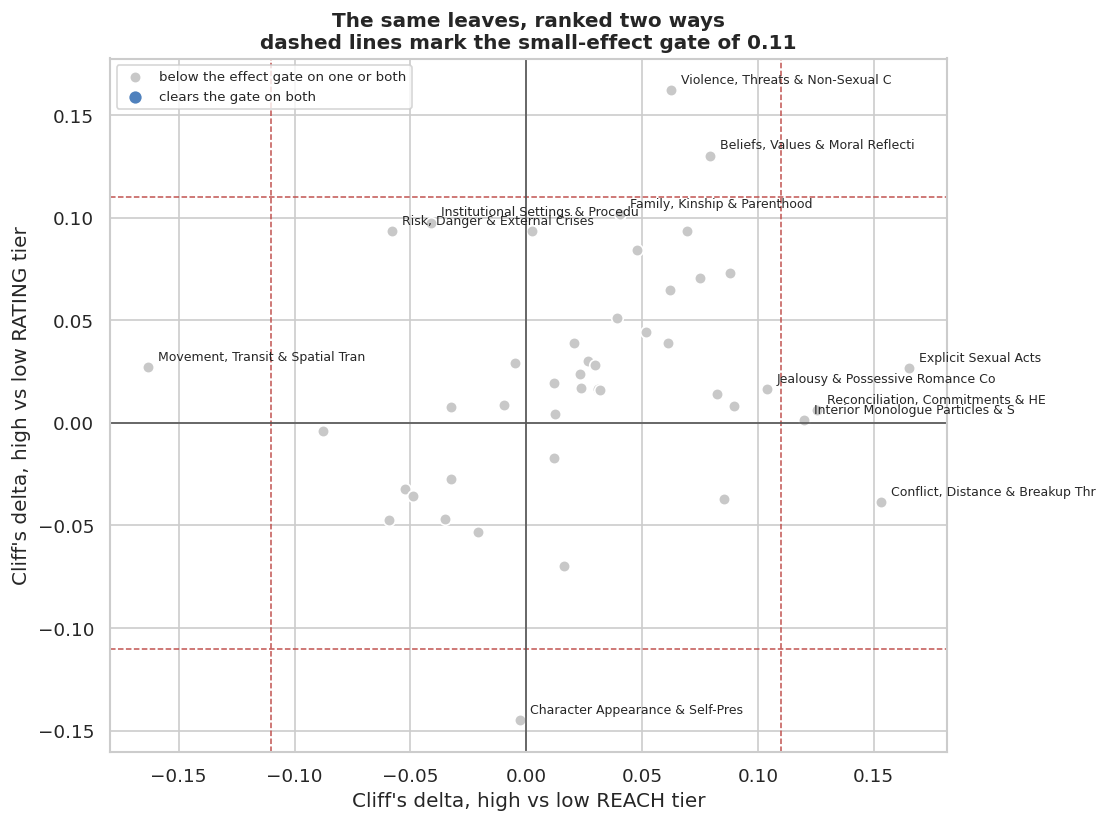

In [15]:
fig, ax = plt.subplots(figsize=(9, 7.5))
both = channel_deltas["rating_clears_gate"] & channel_deltas["reach_clears_gate"]
ax.scatter(channel_deltas.loc[~both, "delta_reach"], channel_deltas.loc[~both, "delta_rating"],
           s=48, color="#c8c8c8", edgecolor="white", label="below the effect gate on one or both")
ax.scatter(channel_deltas.loc[both, "delta_reach"], channel_deltas.loc[both, "delta_rating"],
           s=70, color="#4f81bd", edgecolor="white", label="clears the gate on both")
for level in (GATE, -GATE):
    ax.axhline(level, color="#c0504d", ls="--", lw=0.9)
    ax.axvline(level, color="#c0504d", ls="--", lw=0.9)
ax.axhline(0, color="#555555", lw=1)
ax.axvline(0, color="#555555", lw=1)
for row in channel_deltas.reindex(
    channel_deltas[["delta_rating", "delta_reach"]].abs().max(axis=1).nlargest(12).index
).itertuples():
    short = str(row.label).split(" — ")[-1]
    ax.annotate(short[:32], (row.delta_reach, row.delta_rating),
                textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax.set_xlabel("Cliff's delta, high vs low REACH tier")
ax.set_ylabel("Cliff's delta, high vs low RATING tier")
ax.set_title("The same leaves, ranked two ways\n"
             "dashed lines mark the small-effect gate of 0.11")
ax.legend(fontsize=8, loc="upper left")
ctx.save_figure(fig, "rating_vs_reach_deltas")
plt.show()

In [16]:
print("Leaves that discriminate on rating but not on reach — the quality-specific findings:")
quality_specific = channel_deltas[
    channel_deltas["rating_clears_gate"] & ~channel_deltas["reach_clears_gate"]
]
display(quality_specific[["label", "delta_rating", "delta_reach"]].round(4))

print("\nLeaves that discriminate on reach but not on rating — the market-specific ones:")
reach_specific = channel_deltas[
    channel_deltas["reach_clears_gate"] & ~channel_deltas["rating_clears_gate"]
]
display(reach_specific[["label", "delta_rating", "delta_reach"]].round(4))

Leaves that discriminate on rating but not on reach — the quality-specific findings:


,label,delta_rating,delta_reach
0,"Violence, Threats & Non-Sexual Coercion",0.1623,0.0627
1,"Beliefs, Values & Moral Reflection",0.1304,0.0793
44,Character Appearance & Self-Presentation,-0.1448,-0.0028



Leaves that discriminate on reach but not on rating — the market-specific ones:


,label,delta_rating,delta_reach
18,"Movement, Transit & Spatial Transition",0.0273,-0.1632
19,Explicit Sexual Acts,0.0267,0.1652
30,"Reconciliation, Commitments & HEA",0.0061,0.1256
32,Interior Monologue Particles & Self-Talk,0.0014,0.1198
39,"Conflict, Distance & Breakup Threats",-0.0385,0.1530


**This is the most informative table in the notebook, and the separation is almost total: no
leaf clears the gate on both channels.**

*Quality-specific.* Violence and non-sexual coercion (+0.162), moral and value reflection
(+0.130), and character appearance (−0.145). These are the findings notebooks 01 to 05 were
built on, and they are invisible to the reach channel — appearance in particular has a reach
delta of −0.003, indistinguishable from nothing.

*Reach-specific, and none of them a quality finding.*

- **Explicit sexual acts**: +0.165 on reach, +0.027 on rating. Explicitness travels with
  audience size and not with appreciation. This sharpens H1 considerably: the reason the
  "love over sex" trade-off failed is that explicit content sells without being liked more.
- **Conflict, distance and breakup threats**: +0.153 on reach, −0.039 on rating. The one
  dark leaf that went the wrong way for H5 turns out to be a reach variable. Couple conflict
  attracts readers and does not satisfy them.
- **Reconciliation and HEA**: +0.126 on reach, +0.006 on rating. H2's null result was a
  quality-channel null. On reach, HEA content is one of the strongest signals in the corpus —
  which fits a genre where the guaranteed happy ending is the marketing promise.
- **Movement and transit**: −0.163 on reach. Widely-read books spend less of their prose on
  getting characters from place to place. Plausibly a craft marker again.
- **Interior monologue particles**: +0.120 on reach, +0.001 on rating.

The delta vectors correlate at only r = 0.19 across 45 leaves, not distinguishable from zero
at this n. Thirty-five of forty-five point the same direction, which sounds like agreement
until one notices that most of those thirty-five are near zero on both — agreement about
nothing. Where either channel has something to say, they say different things.

## 6. Is the quality channel an artefact of how it was built?

The quality channel involves three analyst choices: Bayesian shrinkage toward the corpus mean,
reliability weighting, and keeping books with very few ratings. Each could in principle
manufacture a result. The check is to re-fit the headline leaves four ways and see whether
anything moves.

In [17]:
headline_leaves = (
    channel_deltas.reindex(channel_deltas["delta_rating"].abs().nlargest(8).index)["feature"]
    .tolist()
)
variants = {
    "shrunk, weighted (primary)": dict(outcome=QUALITY, weights=WEIGHT, subset=None),
    "shrunk, unweighted": dict(outcome=QUALITY, weights=None, subset=None),
    "raw rating, unweighted": dict(outcome=QUALITY_RAW, weights=None, subset=None),
    f"raw rating, n >= {MIN_RATINGS}": dict(
        outcome=QUALITY_RAW, weights=None, subset=f"n_ratings >= {MIN_RATINGS}"),
}

rows = []
for leaf in headline_leaves:
    for name, spec in variants.items():
        subset = frame.query(spec["subset"]) if spec["subset"] else frame
        work = subset.copy()
        work["_y"] = standardised(work[spec["outcome"]])
        work["_x"] = standardised(work[leaf])
        fit = mdl.fit_ols(
            work, "_y", ["_x", *CONTROLS], categorical=CATEGORICAL, cluster=CLUSTER,
            weights=spec["weights"], name=f"{leaf}|{name}",
        )
        row = fit.coefficients[fit.coefficients["term"] == "_x"].iloc[0]
        rows.append({
            "feature": leaf, "label": leaf_labels.get(leaf, leaf), "variant": name,
            "beta": float(row["coefficient"]), "se": float(row["std_error"]),
            "p_value": float(row["p_value"]), "n_obs": fit.n_obs,
        })
sensitivity = pd.DataFrame(rows)
ctx.save_table(sensitivity, "quality_channel_sensitivity")

wide = sensitivity.pivot_table(index="label", columns="variant", values="beta")
wide = wide[list(variants)]
wide["max_abs_spread"] = wide.max(axis=1) - wide.min(axis=1)
wide["sign_stable"] = (np.sign(wide[list(variants)]).nunique(axis=1) == 1)
display(wide.round(4))

primary_col = "shrunk, weighted (primary)"
unweighted_col = "shrunk, unweighted"
ratio = (wide[primary_col].abs() / wide[unweighted_col].abs().replace(0, np.nan)).median()
print(
    f"\nSign stable across all four specifications: "
    f"{int(wide['sign_stable'].sum())} of {len(wide)} leaves.\n"
    f"Largest spread in standardised beta across specifications: "
    f"{wide['max_abs_spread'].max():.4f}.\n"
)
print(
    f"The direction of every headline leaf survives all four ways of measuring quality, which is\n"
    f"the check that matters. But the magnitudes do not: the weighted specification returns betas\n"
    f"about {ratio:.1f}x the unweighted ones, consistently across leaves.\n"
)

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/tables/quality_channel_sensitivity.csv  (32 rows)


variant,"shrunk, weighted (primary)","shrunk, unweighted","raw rating, unweighted","raw rating, n >= 30",max_abs_spread,sign_stable
label,,,,,,
"Beliefs, Values & Moral Reflection",0.0451,0.0117,0.0213,0.0167,0.0334,True
Character Appearance & Self-Presentation,-0.1390,-0.0835,-0.0721,-0.0882,0.0669,True
"Emotional Safety, Reassurance & Caretaking",0.0431,0.0262,0.0166,0.0217,0.0265,True
"Family, Kinship & Parenthood",0.0274,0.0336,0.0595,0.0611,0.0337,True
Institutional Settings & Procedures,0.0626,0.0286,0.0242,0.0372,0.0384,True
"Mystery, Suspense & Investigation",0.0344,0.0253,0.0412,0.0359,0.0158,True
"Risk, Danger & External Crises",0.0095,0.0089,0.0156,0.0187,0.0098,True
"Violence, Threats & Non-Sexual Coercion",0.1405,0.0820,0.0678,0.0724,0.0727,True



Sign stable across all four specifications: 8 of 8 leaves.
Largest spread in standardised beta across specifications: 0.0727.

The direction of every headline leaf survives all four ways of measuring quality, which is
the check that matters. But the magnitudes do not: the weighted specification returns betas
about 1.7x the unweighted ones, consistently across leaves.



  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/06_goodreads_validation/figures/quality_channel_sensitivity.png


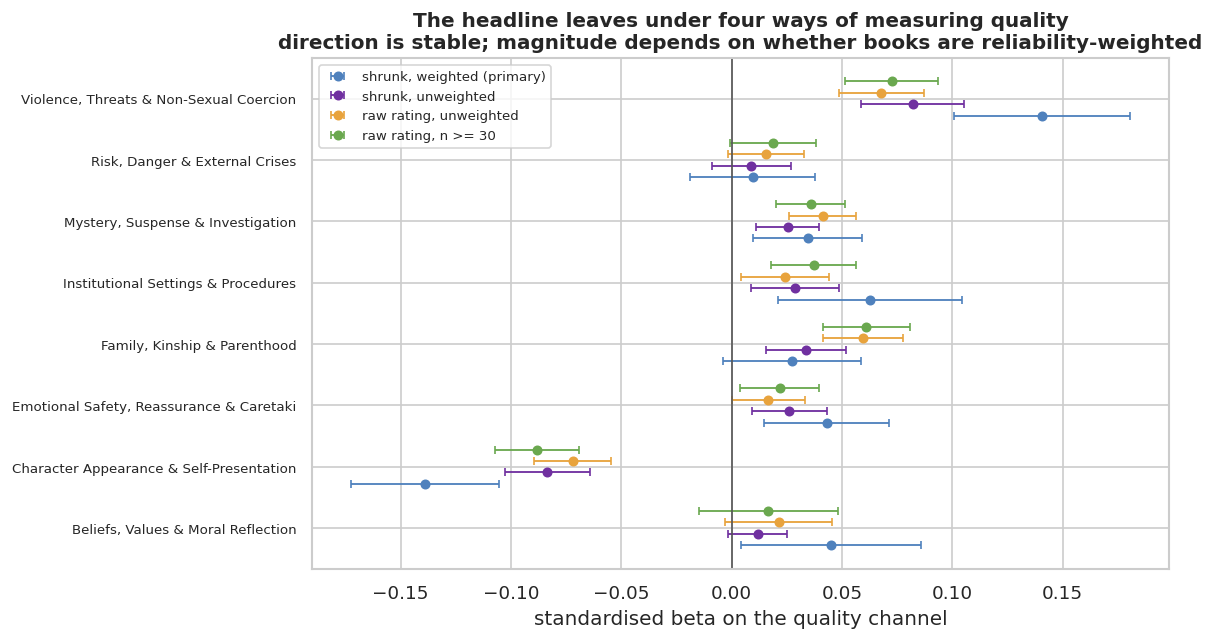

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))
order = wide.index.tolist()
offsets = np.linspace(-0.28, 0.28, len(variants))
for offset, (name, colour) in zip(offsets, zip(
        variants, ["#4f81bd", "#7030a0", "#e8a33d", "#6aa84f"])):
    subset = sensitivity[sensitivity["variant"] == name].set_index("label").reindex(order)
    positions = np.arange(len(order)) + offset
    ax.errorbar(subset["beta"], positions, xerr=1.96 * subset["se"], fmt="o",
                color=colour, ms=5, capsize=2.5, lw=1.1, label=name)
ax.axvline(0, color="#555555", lw=1)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels([s.split(" — ")[-1][:40] for s in order], fontsize=8)
ax.set_xlabel("standardised beta on the quality channel")
ax.set_title("The headline leaves under four ways of measuring quality\n"
             "direction is stable; magnitude depends on whether books are reliability-weighted")
ax.legend(fontsize=8)
fig.tight_layout()
ctx.save_figure(fig, "quality_channel_sensitivity")
plt.show()

### Why weighting roughly doubles the coefficients

This is not a problem with the weighting, and it is not evidence that the weighted estimates
are inflated. It is the expected consequence of measurement error in the outcome.

A book with 12 ratings has an average that is mostly noise. Including it unweighted adds
variance to the outcome that no predictor can explain, which drags every standardised
coefficient toward zero — classical attenuation. Weighting by reliability `v/(v+m)` down-weights
exactly those books, so the remaining signal is less diluted and the coefficients come back up.
The `n >= 30` column shows the same thing done bluntly by exclusion rather than smoothly by
weighting, and lands near the unweighted values because it still treats a 30-rating book and a
30,000-rating book as equally informative.

The reporting consequence: **the weighted betas are the better estimates of the association,
and the unweighted ones are the more conservative.** Notebooks 01 to 05 quote Cliff's delta
from unweighted tier comparisons, so every effect size in this analysis sits at the
conservative end.

That is worth being explicit about rather than treating as a technicality, because several
leaves sit just below the 0.11 gate on the unweighted comparison — family and parenthood at
0.102, institutional settings at 0.098, external crisis and emotional safety both at 0.094.
A rating-noise correction of the size seen here would plausibly carry some of them across.
The verdicts in notebook 05 are therefore not knife-edge readings of a true threshold; they
are readings of a deliberately conservative one, and the borderline cases should be described
as borderline rather than as failures.

In [19]:
near_gate = channel_deltas[
    channel_deltas["delta_rating"].abs().between(0.08, GATE)
][["label", "delta_rating", "delta_reach"]]
print(f"Leaves within 0.03 of the {GATE} gate on the rating channel — the borderline set:")
display(near_gate.round(4))

Leaves within 0.03 of the 0.11 gate on the rating channel — the borderline set:


,label,delta_rating,delta_reach
2,"Family, Kinship & Parenthood",0.1017,0.0406
3,Institutional Settings & Procedures,0.0977,-0.0411
4,"Risk, Danger & External Crises",0.0936,-0.0579
5,"Emotional Safety, Reassurance & Caretaking",0.0935,0.0693
6,"Mystery, Suspense & Investigation",0.0934,0.0026
7,Unwanted or Coercive Sexual Contact,0.0845,0.0479


## 7. What the second channel added

**The two channels are nearly disjoint, and that is the headline.** No taxonomy leaf clears the
effect gate on both. The three that discriminate on rating are invisible to reach; the five
that discriminate on reach are flat on rating. Across all 45 leaves the two effect-size
vectors correlate at r = 0.19, not distinguishable from zero. Whatever notebooks 01 to 05
measured, it was not popularity in disguise — which is the validation this notebook was
there to provide.

**Three of notebook 05's puzzles resolve once the second channel is available.** Each was a
hypothesis that failed on rating, and each turns out to be a reach effect:

| Notebook 05 result | With the reach channel |
|---|---|
| H1: explicitness did not trade off against emotional intimacy | Explicitness is a reach variable (+0.165) with almost no rating effect (+0.027). It sells; it is not liked more. |
| H2: HEA signalling showed no rating effect | HEA is one of the strongest reach signals (+0.126). The genre promise is a marketing promise. |
| H5: couple conflict was the dark leaf pointing the wrong way | Conflict is a reach variable (+0.153) that is mildly negative on rating (−0.039). It attracts and does not satisfy. |

None of these were null results. They were results in the wrong channel, and a single-outcome
analysis would have reported them as nulls and moved on.

**Reach is an exposure measure, not an appeal measure.** Controls explain 12% of it, but
through length, genre and shelf-time rather than anything a reader chose: −0.10 log-ratings
per publication year, +1.09 per log-page, +1.31 for young-adult romance. A weak theme effect
on reach means "this is not a theme-driven variable", not "this theme does not matter".

**High reach goes with middling ratings.** 42% of mid-rated books sit in the top reach tier
against 23% of low-rated and 35% of high-rated books. Reaching a wide audience means being
read by people outside the natural readership, who rate closer to the middle. So the two
channels are not merely independent, they are non-monotonically related, and a theme that
raises reach can lower measured rating without being worse.

**The quality channel's direction is robust; its magnitude is not.** All eight headline leaves
keep their sign across shrunk-weighted, shrunk-unweighted, raw, and `n >= 30` specifications.
Weighted betas run about twice the unweighted ones, which is expected attenuation from
rating noise rather than a problem — but it does mean the effect sizes quoted throughout this
analysis are conservative, and that the borderline leaves listed above deserve to be called
borderline rather than negative.

**One limit to keep in view.** Neither channel measures literary quality, and neither measures
reader preference cleanly. Goodreads ratings come from people who chose to read a particular
romance novel, so a high rating partly reflects a good match between book and reader rather
than a better book. Everything here is conditional on that self-selection.

In [20]:
print("Next: 07_qualitative_triangulation.ipynb — reading actual sentences from books at the")
print("extremes of these indices, to check that the numbers mean what they appear to mean.")

Next: 07_qualitative_triangulation.ipynb — reading actual sentences from books at the
extremes of these indices, to check that the numbers mean what they appear to mean.
